In [19]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

sys.path.append('../upper/')
import upper

In [26]:
file = h5py.File(r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/sphere_20241202_recon_all.h5py')
file['recon_data_all'].attrs['livetime_sec']


872973.9943

## Checked the projected DM rate

Text(0, 0.5, '$dR / dq_z$ (Counts/keV/s)')

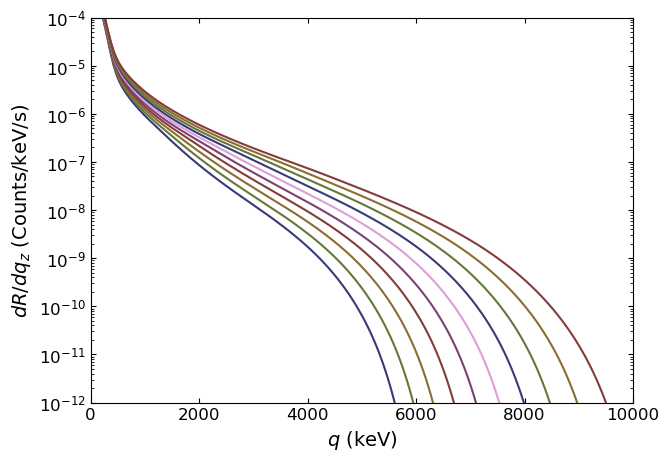

In [5]:
drdqzn_1ev_file = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/drdqz_100mevthr_nanosphere_8.30e-02_coarse_ampdepsigma_1e+00.npz'
drdqzn_1ev = np.load(drdqzn_1ev_file)

q_kev = drdqzn_1ev['bc_kev']
drdqzn = drdqzn_1ev['drdqzn']
mx = drdqzn_1ev['mx_list']
alpha = drdqzn_1ev['alpha_list']

for i in range(10, 20):
    plt.plot(q_kev, drdqzn[23, i])

plt.xlim(0, 10000)
plt.ylim(1e-12, 1e-4)
plt.yscale('log')

plt.xlabel('$q$ (keV)')
plt.ylabel('$dR / dq_z$ (Counts/keV/s)')

#### Optimum interval alpha limits

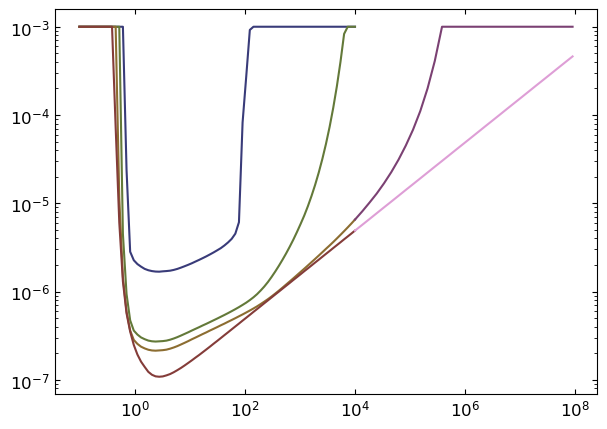

In [25]:
sphere = 'sphere_20250103'
datasets = ['coarse', 'coarse_extended_right']
mphi_lists = [[10, 1, 0.1, 0], [0.1, 0]]

for i, dataset in enumerate(datasets):
    for mphi in mphi_lists[i]:
        if mphi == 0:
            mphi_prefix = 'massless'
        else:
            mphi_prefix = f'{mphi:.0e}'

        file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{dataset}_{mphi_prefix}.npz'
        npz_file = np.load(file)

        mx = npz_file['mx_gev']
        alpha_lim = npz_file['alpha_lim']

        plt.plot(mx, alpha_lim)

plt.xscale('log')
plt.yscale('log')
